In [55]:
print("Versão do Python:")
!python --version

Versão do Python:
Python 3.14.4


## Libraries


In [56]:
!pip install -r requirements.txt

## Importa Bibliotecas base

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

## Ler arquivos CSV's

In [58]:
base_cadastros = pd.read_csv("data/base_cadastral.csv", sep=";" )
base_info = pd.read_csv("data/base_info.csv", sep=";" )
base_pagamentos_desenvolvimento = pd.read_csv("data/base_pagamentos_desenvolvimento.csv", sep=";" )
base_pagamentos_teste = pd.read_csv("data/base_pagamentos_teste.csv", sep=";" )

display(base_cadastros.head())
display(base_info.head())
display(base_pagamentos_desenvolvimento.head())
display(base_pagamentos_teste.head())

,ID_CLIENTE,DATA_CADASTRO,DDD,FLAG_PF,SEGMENTO_INDUSTRIAL,DOMINIO_EMAIL,PORTE,CEP_2_DIG
0,1661240395903230676,2013-08-22,99,NaN,Serviços,YAHOO,PEQUENO,65
1,8274986328479596038,2017-01-25,31,NaN,Comércio,YAHOO,MEDIO,77
2,345447888460137901,2000-08-15,75,NaN,Serviços,HOTMAIL,PEQUENO,48
3,1003144834589372198,2017-08-06,49,NaN,Serviços,OUTLOOK,PEQUENO,89
4,324916756972236008,2011-02-14,88,NaN,Serviços,GMAIL,GRANDE,62


,ID_CLIENTE,SAFRA_REF,RENDA_MES_ANTERIOR,NO_FUNCIONARIOS
0,1661240395903230676,2018-09,16913.0,NaN
1,8274986328479596038,2018-09,106430.0,141.0
2,345447888460137901,2018-09,707439.0,99.0
3,1003144834589372198,2018-09,239659.0,96.0
4,324916756972236008,2018-09,203123.0,103.0


,ID_CLIENTE,SAFRA_REF,DATA_EMISSAO_DOCUMENTO,DATA_PAGAMENTO,DATA_VENCIMENTO,VALOR_A_PAGAR,TAXA
0,1661240395903230676,2018-08,2018-08-17,2018-09-06,2018-09-06,35516.41,6.99
1,1661240395903230676,2018-08,2018-08-19,2018-09-11,2018-09-10,17758.21,6.99
2,1661240395903230676,2018-08,2018-08-26,2018-09-18,2018-09-17,17431.96,6.99
3,1661240395903230676,2018-08,2018-08-30,2018-10-11,2018-10-05,1341.00,6.99
4,1661240395903230676,2018-08,2018-08-31,2018-09-20,2018-09-20,21309.85,6.99


,ID_CLIENTE,SAFRA_REF,DATA_EMISSAO_DOCUMENTO,DATA_VENCIMENTO,VALOR_A_PAGAR,TAXA
0,5058298901476893676,2021-07,2021-07-14,2021-08-04,11204.75,4.99
1,274692171162531764,2021-07,2021-07-08,2021-08-23,60718.50,5.99
2,274692171162531764,2021-07,2021-07-11,2021-08-25,60718.50,5.99
3,274692171162531764,2021-07,2021-07-16,2021-08-30,62250.00,5.99
4,465309249432033993,2021-07,2021-07-05,2021-07-30,26593.95,6.99


In [59]:
base_pagamentos_desenvolvimento["DATA_EMISSAO_DOCUMENTO"] = pd.to_datetime(base_pagamentos_desenvolvimento["DATA_EMISSAO_DOCUMENTO"], errors="coerce")
base_pagamentos_desenvolvimento["DATA_PAGAMENTO"] = pd.to_datetime(base_pagamentos_desenvolvimento["DATA_PAGAMENTO"], errors="coerce")
base_pagamentos_desenvolvimento["DATA_VENCIMENTO"] = pd.to_datetime(base_pagamentos_desenvolvimento["DATA_VENCIMENTO"], errors="coerce")

base_pagamentos_teste["DATA_EMISSAO_DOCUMENTO"] = pd.to_datetime(base_pagamentos_teste["DATA_EMISSAO_DOCUMENTO"], errors="coerce")
base_pagamentos_teste["DATA_VENCIMENTO"] = pd.to_datetime(base_pagamentos_teste["DATA_VENCIMENTO"], errors="coerce")

base_cadastros["DATA_CADASTRO"] = pd.to_datetime(base_cadastros["DATA_CADASTRO"], errors="coerce")

## Criar Varivel de Inadimplencia

In [60]:
base_pagamentos_desenvolvimento["INADIMPLENTE"] = (base_pagamentos_desenvolvimento["DATA_PAGAMENTO"] >= base_pagamentos_desenvolvimento["DATA_VENCIMENTO"]+pd.Timedelta(days=5)).astype(int)
base_pagamentos_desenvolvimento["INADIMPLENTE"].value_counts()

INADIMPLENTE
0    71978
1     5436
Name: count, dtype: int64

## Marge Base

<class 'pandas.DataFrame'>
RangeIndex: 77414 entries, 0 to 77413
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   ID_CLIENTE              77414 non-null  int64         
 1   SAFRA_REF               77414 non-null  str           
 2   RENDA_MES_ANTERIOR      71282 non-null  float64       
 3   NO_FUNCIONARIOS         69827 non-null  float64       
 4   DATA_EMISSAO_DOCUMENTO  77414 non-null  datetime64[us]
 5   DATA_PAGAMENTO          77414 non-null  datetime64[us]
 6   DATA_VENCIMENTO         77414 non-null  datetime64[us]
 7   VALOR_A_PAGAR           76244 non-null  float64       
 8   TAXA                    77414 non-null  float64       
 9   INADIMPLENTE            77414 non-null  int64         
 10  DATA_CADASTRO           77414 non-null  datetime64[us]
 11  DDD                     70000 non-null  str           
 12  FLAG_PF                 219 non-null    str           
 1

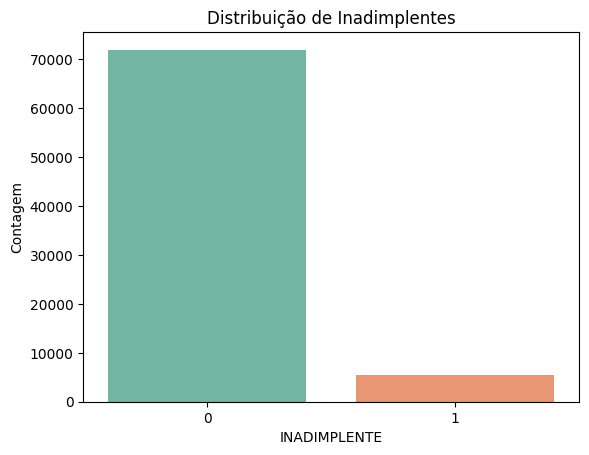

In [61]:
base_mensal=pd.merge(base_info, base_pagamentos_desenvolvimento,  on=["ID_CLIENTE", "SAFRA_REF"], how="right")
base_model = pd.merge(base_mensal, base_cadastros, on=["ID_CLIENTE"], how="inner")
base_model["MISSING"] = np.zeros(len(base_model), dtype=int)
sns.barplot(x=base_model["INADIMPLENTE"].value_counts().index, y=base_model["INADIMPLENTE"].value_counts().values,  hue=base_model["INADIMPLENTE"].value_counts().index,palette="Set2", legend=False)

plt.title("Distribuição de Inadimplentes")
plt.ylabel("Contagem")
base_model.info()

In [62]:
base_mensal=pd.merge(base_info, base_pagamentos_teste,  on=["ID_CLIENTE", "SAFRA_REF"], how="right")
base_submit = pd.merge(base_mensal, base_cadastros, on=["ID_CLIENTE"], how="left")
base_submit["MISSING"] = np.zeros(len(base_submit), dtype=int)
base_submit.info()

<class 'pandas.DataFrame'>
RangeIndex: 12275 entries, 0 to 12274
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   ID_CLIENTE              12275 non-null  int64         
 1   SAFRA_REF               12275 non-null  str           
 2   RENDA_MES_ANTERIOR      11549 non-null  float64       
 3   NO_FUNCIONARIOS         11108 non-null  float64       
 4   DATA_EMISSAO_DOCUMENTO  12275 non-null  datetime64[us]
 5   DATA_VENCIMENTO         12275 non-null  datetime64[us]
 6   VALOR_A_PAGAR           12144 non-null  float64       
 7   TAXA                    12275 non-null  float64       
 8   DATA_CADASTRO           12237 non-null  datetime64[us]
 9   DDD                     10898 non-null  str           
 10  FLAG_PF                 47 non-null     str           
 11  SEGMENTO_INDUSTRIAL     12021 non-null  str           
 12  DOMINIO_EMAIL           12067 non-null  str           
 1

### Split base MODEL para TREINO e TESTE

In [63]:
safras_ordenadas = sorted(base_model["SAFRA_REF"].unique())

n_test_safras = 5

safras_train = safras_ordenadas[:-n_test_safras]
safras_test  = safras_ordenadas[-n_test_safras:]

train = base_model[base_model["SAFRA_REF"].isin(safras_train)]
train= train.drop(columns=["DATA_PAGAMENTO"])
test  = base_model[base_model["SAFRA_REF"].isin(safras_test)]

print(f"Safras treino: {safras_train[0]} -> {safras_train[-1]}")
print(f"Safras teste:  {safras_test[0]} -> {safras_test[-1]}")
print(f"Treino: {len(train):,} linhas | Teste: {len(test):,} linhas")
print(f"Proporção Teste/Treino: {len(test)/len(train):.2%}")


Safras treino: 2018-08 -> 2021-01
Safras teste:  2021-02 -> 2021-06
Treino: 65,540 linhas | Teste: 11,874 linhas
Proporção Teste/Treino: 18.12%


## Imputações na base de TRAIN, Teste e Submit

In [64]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline

In [65]:
class ImputacaoFLAG_PF(BaseEstimator, TransformerMixin):
    def __init__(self, col="FLAG_PF", PJ=0, PF=1):
        self.col = col
        self.PF_PJ = {"X":PF, np.nan:PJ}

    def fit(self, X,y=None):
        self.fitted_ = True
        return self

    def transform(self, X):
        X = X.copy()
        X[self.col] = X[self.col].map(self.PF_PJ)
        
        return X


In [66]:
class ImputacaoValueUnknown(BaseEstimator, TransformerMixin):
    def __init__(self, col="DOMINIO_EMAIL", fill_value="UNKNOWN"):
        self.col = col
        self.fill_value = fill_value

    def fit(self, X, y=None):
        self.fitted_ = True
        return self

    def transform(self, X):
        X = X.copy()
        
        X[self.col] = X[self.col].fillna(self.fill_value)
        
        return X

In [67]:
class ImputacaoHierarquicaValor(BaseEstimator, TransformerMixin):
    def __init__(self, col="VALOR_A_PAGAR"):
        self.col = col
        
    def fit(self, X, y=None):
        self.med_cs_ = X.groupby(["ID_CLIENTE", "SAFRA_REF"])[self.col].median().reset_index()
        self.med_cs_.columns = ["ID_CLIENTE", "SAFRA_REF", "med_cs"]
        
        self.med_c_ = X.groupby("ID_CLIENTE")[self.col].median().reset_index()
        self.med_c_.columns = ["ID_CLIENTE", "med_c"]
        
        self.med_global_ = X[self.col].median()
        
        return self

    def transform(self, X):
        X = X.copy()
        
        # flag de missing
        X["MISSING"] += X[self.col].isna().astype(int)
        
        X = X.merge(self.med_cs_, on=["ID_CLIENTE", "SAFRA_REF"], how="left")
        X = X.merge(self.med_c_, on="ID_CLIENTE", how="left")
        
        # Imputação Hierárquica
        X[self.col] = X[self.col].fillna(X["med_cs"])
        X[self.col] = X[self.col].fillna(X["med_c"])
        X[self.col] = X[self.col].fillna(self.med_global_)
        
        X = X.drop(columns=["med_cs", "med_c"])
        
        return X

In [68]:
class ImputacaoCEP2(BaseEstimator, TransformerMixin):
    def __init__(self, col="CEP_2_DIG"):
        self.col = col

    def fit(self, X, y=None):
        cep_temp = X[self.col].replace('na', np.nan).astype("Int16")
        self.moda_ = cep_temp.mode()[0]
        return self

    def transform(self, X):
        X = X.copy()
        X[self.col] = X[self.col].replace('na', np.nan).astype("Int16")
        X[self.col] = X[self.col].fillna(self.moda_)
        return X

In [69]:
class ImputacaoDDDGeografico(BaseEstimator, TransformerMixin):
    def __init__(self, col_ddd="DDD", col_cep="CEP_2_DIG"):
        self.col_ddd = col_ddd
        self.col_cep = col_cep
        
        self.ddd_para_cep2_ranges = {
            11: [(1, 11)], 12: [(12, 12)], 13: [(13, 13)], 14: [(14, 14)], 15: [(15, 15)],
            16: [(16, 16)], 17: [(17, 17)], 18: [(18, 18)], 19: [(19, 19)], 21: [(20, 26)],
            22: [(27, 28)], 27: [(29, 29)], 31: [(30, 33), (35, 35)], 32: [(36, 36)],
            33: [(39, 39)], 34: [(34, 34)], 37: [(37, 37)], 38: [(38, 38)], 71: [(40, 41)],
            73: [(47, 47)], 74: [(43, 44)], 75: [(42, 42)], 77: [(45, 46)], 79: [(48, 49)],
            81: [(50, 50), (52, 55)], 87: [(51, 51), (56, 56)], 82: [(57, 57)], 83: [(58, 58)],
            84: [(59, 59)], 85: [(60, 61)], 88: [(62, 63)], 86: [(64, 64)], 98: [(65, 65)],
            99: [(66, 66)], 91: [(67, 67)], 93: [(68, 68)], 96: [(69, 69)], 61: [(70, 73)],
            62: [(74, 74), (76, 76)], 64: [(75, 75)], 63: [(77, 77)], 65: [(78, 78)],
            67: [(79, 79)], 41: [(80, 83)], 42: [(84, 84)], 43: [(86, 86)], 44: [(85, 85), (87, 87)],
            48: [(88, 88)], 47: [(89, 89)], 51: [(90, 92), (94, 94)], 53: [(96, 96)],
            54: [(93, 93), (95, 95), (99, 99)], 55: [(97, 97), (98, 98)],
        }
        
        # Gerar o mapeamento inverso (CEP -> DDD)
        self.cep2_para_ddd = {
            cep: ddd
            for ddd, ranges in self.ddd_para_cep2_ranges.items()
            for start, end in ranges
            for cep in range(start, end + 1)
        }

    def fit(self, X, y=None):
        self.fitted_ = True
        return self

    def transform(self, X):
        X = X.copy()
        
        # Limpeza da coluna DDD
        X[self.col_ddd] = (
            X[self.col_ddd]
            .astype(str)
            .str.replace(r"\D", "", regex=True)
            .replace("", np.nan)
        )
        X[self.col_ddd] = pd.to_numeric(X[self.col_ddd], errors='coerce').astype("Int16")
        
        # Invalidar DDDs fora da regra de negócio
        valid_ddds = self.ddd_para_cep2_ranges.keys()
        X.loc[~X[self.col_ddd].isin(valid_ddds), self.col_ddd] = pd.NA
        
        # Imputação Geográfica (onde DDD é nulo)
        mask_nulo = X[self.col_ddd].isna()
        X.loc[mask_nulo, self.col_ddd] = (
            X.loc[mask_nulo, self.col_cep]
            .map(self.cep2_para_ddd)
            .astype("Int16")
        )
        
        return X

## Feature Enginner

In [70]:
from sklearn.preprocessing import OrdinalEncoder

class OrdinalEncoderAprendiz(BaseEstimator, TransformerMixin):
    def __init__(self, cols):
        self.cols = cols

    def fit(self, X, y=None):
        X.copy()

        self.encoder_ = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
        self.encoder_.fit(X[self.cols])

        self.mappings_ = {
            col: {cat: idx for idx, cat in enumerate(cats)}
            for col, cats in zip(self.cols, self.encoder_.categories_)
        }

        return self

    def transform(self, X, y=None):
        X.copy()

        X[self.cols] = self.encoder_.transform(X[self.cols])

        return X

    def get_feature_names_out(self, input_features=None):
        return np.array(self.cols)

In [71]:
class DiferencaDiasTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, col_inicio, col_fim, nome_coluna='diferenca_dias'):
        self.col_inicio = col_inicio
        self.col_fim = col_fim
        self.nome_coluna = nome_coluna

    def fit(self, X, y=None):
        self.fitted_ = True
        return self

    def transform(self, X, y=None):
        X = pd.DataFrame(X) if not isinstance(X, pd.DataFrame) else X.copy()

        X[self.col_inicio] = pd.to_datetime(X[self.col_inicio])
        X[self.col_fim] = pd.to_datetime(X[self.col_fim])

        X[self.nome_coluna] = (X[self.col_fim] - X[self.col_inicio]).dt.days

        return X


In [72]:
class SplitSafraTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, col):
        self.col=col

    def fit(self, X, y=None):
        self.fitted_ = True
        return self

    def transform(self, X, y=None):
        X = X.copy()
        
        split = X[self.col].str.split("-", expand=True)
        X[self.col+"_year"] = split[0].astype(int)
        X[self.col+"_month"] = split[1].astype(int)

        return X


In [73]:
class OrdinalCategoricalWithInitTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, col):
        self.col = col
        self.min_date = None

    def fit(self, X, y=None):
        self.min_date = pd.to_datetime(X[self.col]).min()
        return self

    def transform(self, X, y=None):
        X = X.copy()
        
        safra_dt = pd.to_datetime(X[self.col])
        
        X[f"{self.col}_ORDINAL"] = (
            (safra_dt.dt.year - self.min_date.year) * 12 + 
            (safra_dt.dt.month - self.min_date.month)
        )
    
        return X

In [74]:
class DropCols(BaseEstimator, TransformerMixin):
    def __init__(self, cols):
        self.cols=cols

    def fit(self, X, y=None):
        self.fitted_ = True
        return self

    def transform(self, X, y=None):
        X = X.copy()
        
        X=X.drop(columns=self.cols, errors="ignore")

        return X

In [75]:
from sklearn.base import BaseEstimator, TransformerMixin

class MediaHistoricaInadimplencia(BaseEstimator, TransformerMixin):
    def __init__(self, id_col, target_col, date_col):
        self.id_col = id_col
        self.target_col = target_col
        self.date_col = date_col

    def fit(self, X, y=None):
        # não aprende nada global — só garante interface
        return self

    def transform(self, X, y=None):
        X = X.copy()

        # ordena corretamente (CRÍTICO)
        X = X.sort_values([self.id_col, self.date_col])

        # média histórica sem leakage
        X["inad_hist_media"] = (
            X.groupby(self.id_col)[self.target_col]
            .expanding()
            .mean()
            .shift(1)
            .reset_index(level=0, drop=True)
        )

        return X

In [76]:
class MediaHistoricaInadimplencia(BaseEstimator, TransformerMixin):
    def __init__(self, id_col, target_col, date_col):
        self.id_col = id_col
        self.target_col = target_col
        self.date_col = date_col

    def fit(self, X, y=None):
        X = X.sort_values([self.id_col, self.date_col])

        hist = (
            X.groupby(self.id_col)[self.target_col]
            .expanding()
            .mean()
            .shift(1)
            .reset_index(level=0, drop=True)
            .rename("inad_hist_media")
        )

        temp = X[[self.id_col]].copy()
        temp["inad_hist_media"] = hist.values

        self.last_mean_ = temp.groupby(self.id_col)["inad_hist_media"].last()
        self.global_mean_ = X[self.target_col].mean()

        return self

    def transform(self, X):
        X = X.copy()
        X["inad_hist_media"] = (
            X[self.id_col]
            .map(self.last_mean_)
            .fillna(self.global_mean_)
        )
        return X

## Pipilne

In [125]:
from sklearn.preprocessing import OrdinalEncoder

pipeline = Pipeline(steps=[
    ("imputa_PF_PJ", ImputacaoFLAG_PF(col="FLAG_PF", PJ=0, PF=1)),

    ("imputa_email", ImputacaoValueUnknown(col="DOMINIO_EMAIL")),
    ("imputa_segmento_industrial",    ImputacaoValueUnknown(col="SEGMENTO_INDUSTRIAL")),
    ("imputa_porte", ImputacaoValueUnknown(col="PORTE")),

    ("imputa_valor_a_pagar", ImputacaoHierarquicaValor(col="VALOR_A_PAGAR")),
    ("imputa_valor_mes_anterior", ImputacaoHierarquicaValor(col="RENDA_MES_ANTERIOR")),
    ("imputa_no_funcionarios", ImputacaoHierarquicaValor(col="NO_FUNCIONARIOS")),

    ("imputa_cep_2_dig", ImputacaoCEP2(col="CEP_2_DIG")),

    ("imputa_ddd_geografico", ImputacaoDDDGeografico(col_ddd="DDD", col_cep="CEP_2_DIG")),
    

    ("ordinal_encoder", OrdinalEncoderAprendiz(cols=["SEGMENTO_INDUSTRIAL", "DOMINIO_EMAIL", "PORTE","ID_CLIENTE"])),
    
    ("diferenca_dias_emissao_vencimento", DiferencaDiasTransformer(col_inicio="DATA_EMISSAO_DOCUMENTO", col_fim="DATA_VENCIMENTO", nome_coluna="diferenca_emissao_vencimento")),
    ("diferenca_dias_cadastro_emissao", DiferencaDiasTransformer(col_inicio="DATA_CADASTRO", col_fim="DATA_EMISSAO_DOCUMENTO", nome_coluna="diferenca_cadastro_emissao")),

    ("SplitSafra", SplitSafraTransformer(col="SAFRA_REF")),
    ("OrdinalSafra", OrdinalCategoricalWithInitTransformer(col="SAFRA_REF")),
    ("MediaHistoricaInadimplencia", MediaHistoricaInadimplencia(id_col="ID_CLIENTE", target_col="INADIMPLENTE", date_col="SAFRA_REF")),
    
    ("drop_datas", DropCols(cols=["DATA_CADASTRO", "DATA_EMISSAO_DOCUMENTO", "DATA_VENCIMENTO", "DATA_PAGAMENTO","ID_CLIENTE","SAFRA_REF", "SAFRA_REF_year", "MISSING"])),
    
])

# Fit só no treino
pipeline.fit(train)

# Transform em ambos
train_=train.copy()
test_=test.copy()
train_ = pipeline.transform(train_)
test_ = pipeline.transform(test_)
submission = pipeline.transform(base_submit)


In [78]:
train_.info()

<class 'pandas.DataFrame'>
RangeIndex: 65540 entries, 0 to 65539
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID_CLIENTE                    65540 non-null  float64
 1   RENDA_MES_ANTERIOR            65540 non-null  float64
 2   NO_FUNCIONARIOS               65540 non-null  float64
 3   VALOR_A_PAGAR                 65540 non-null  float64
 4   TAXA                          65540 non-null  float64
 5   INADIMPLENTE                  65540 non-null  int64  
 6   DDD                           65540 non-null  Int16  
 7   FLAG_PF                       65540 non-null  int64  
 8   SEGMENTO_INDUSTRIAL           65540 non-null  float64
 9   DOMINIO_EMAIL                 65540 non-null  float64
 10  PORTE                         65540 non-null  float64
 11  CEP_2_DIG                     65540 non-null  Int16  
 12  diferenca_emissao_vencimento  65540 non-null  int64  
 13  diferenca_ca

## Analise Exploratoria Pos Imputação

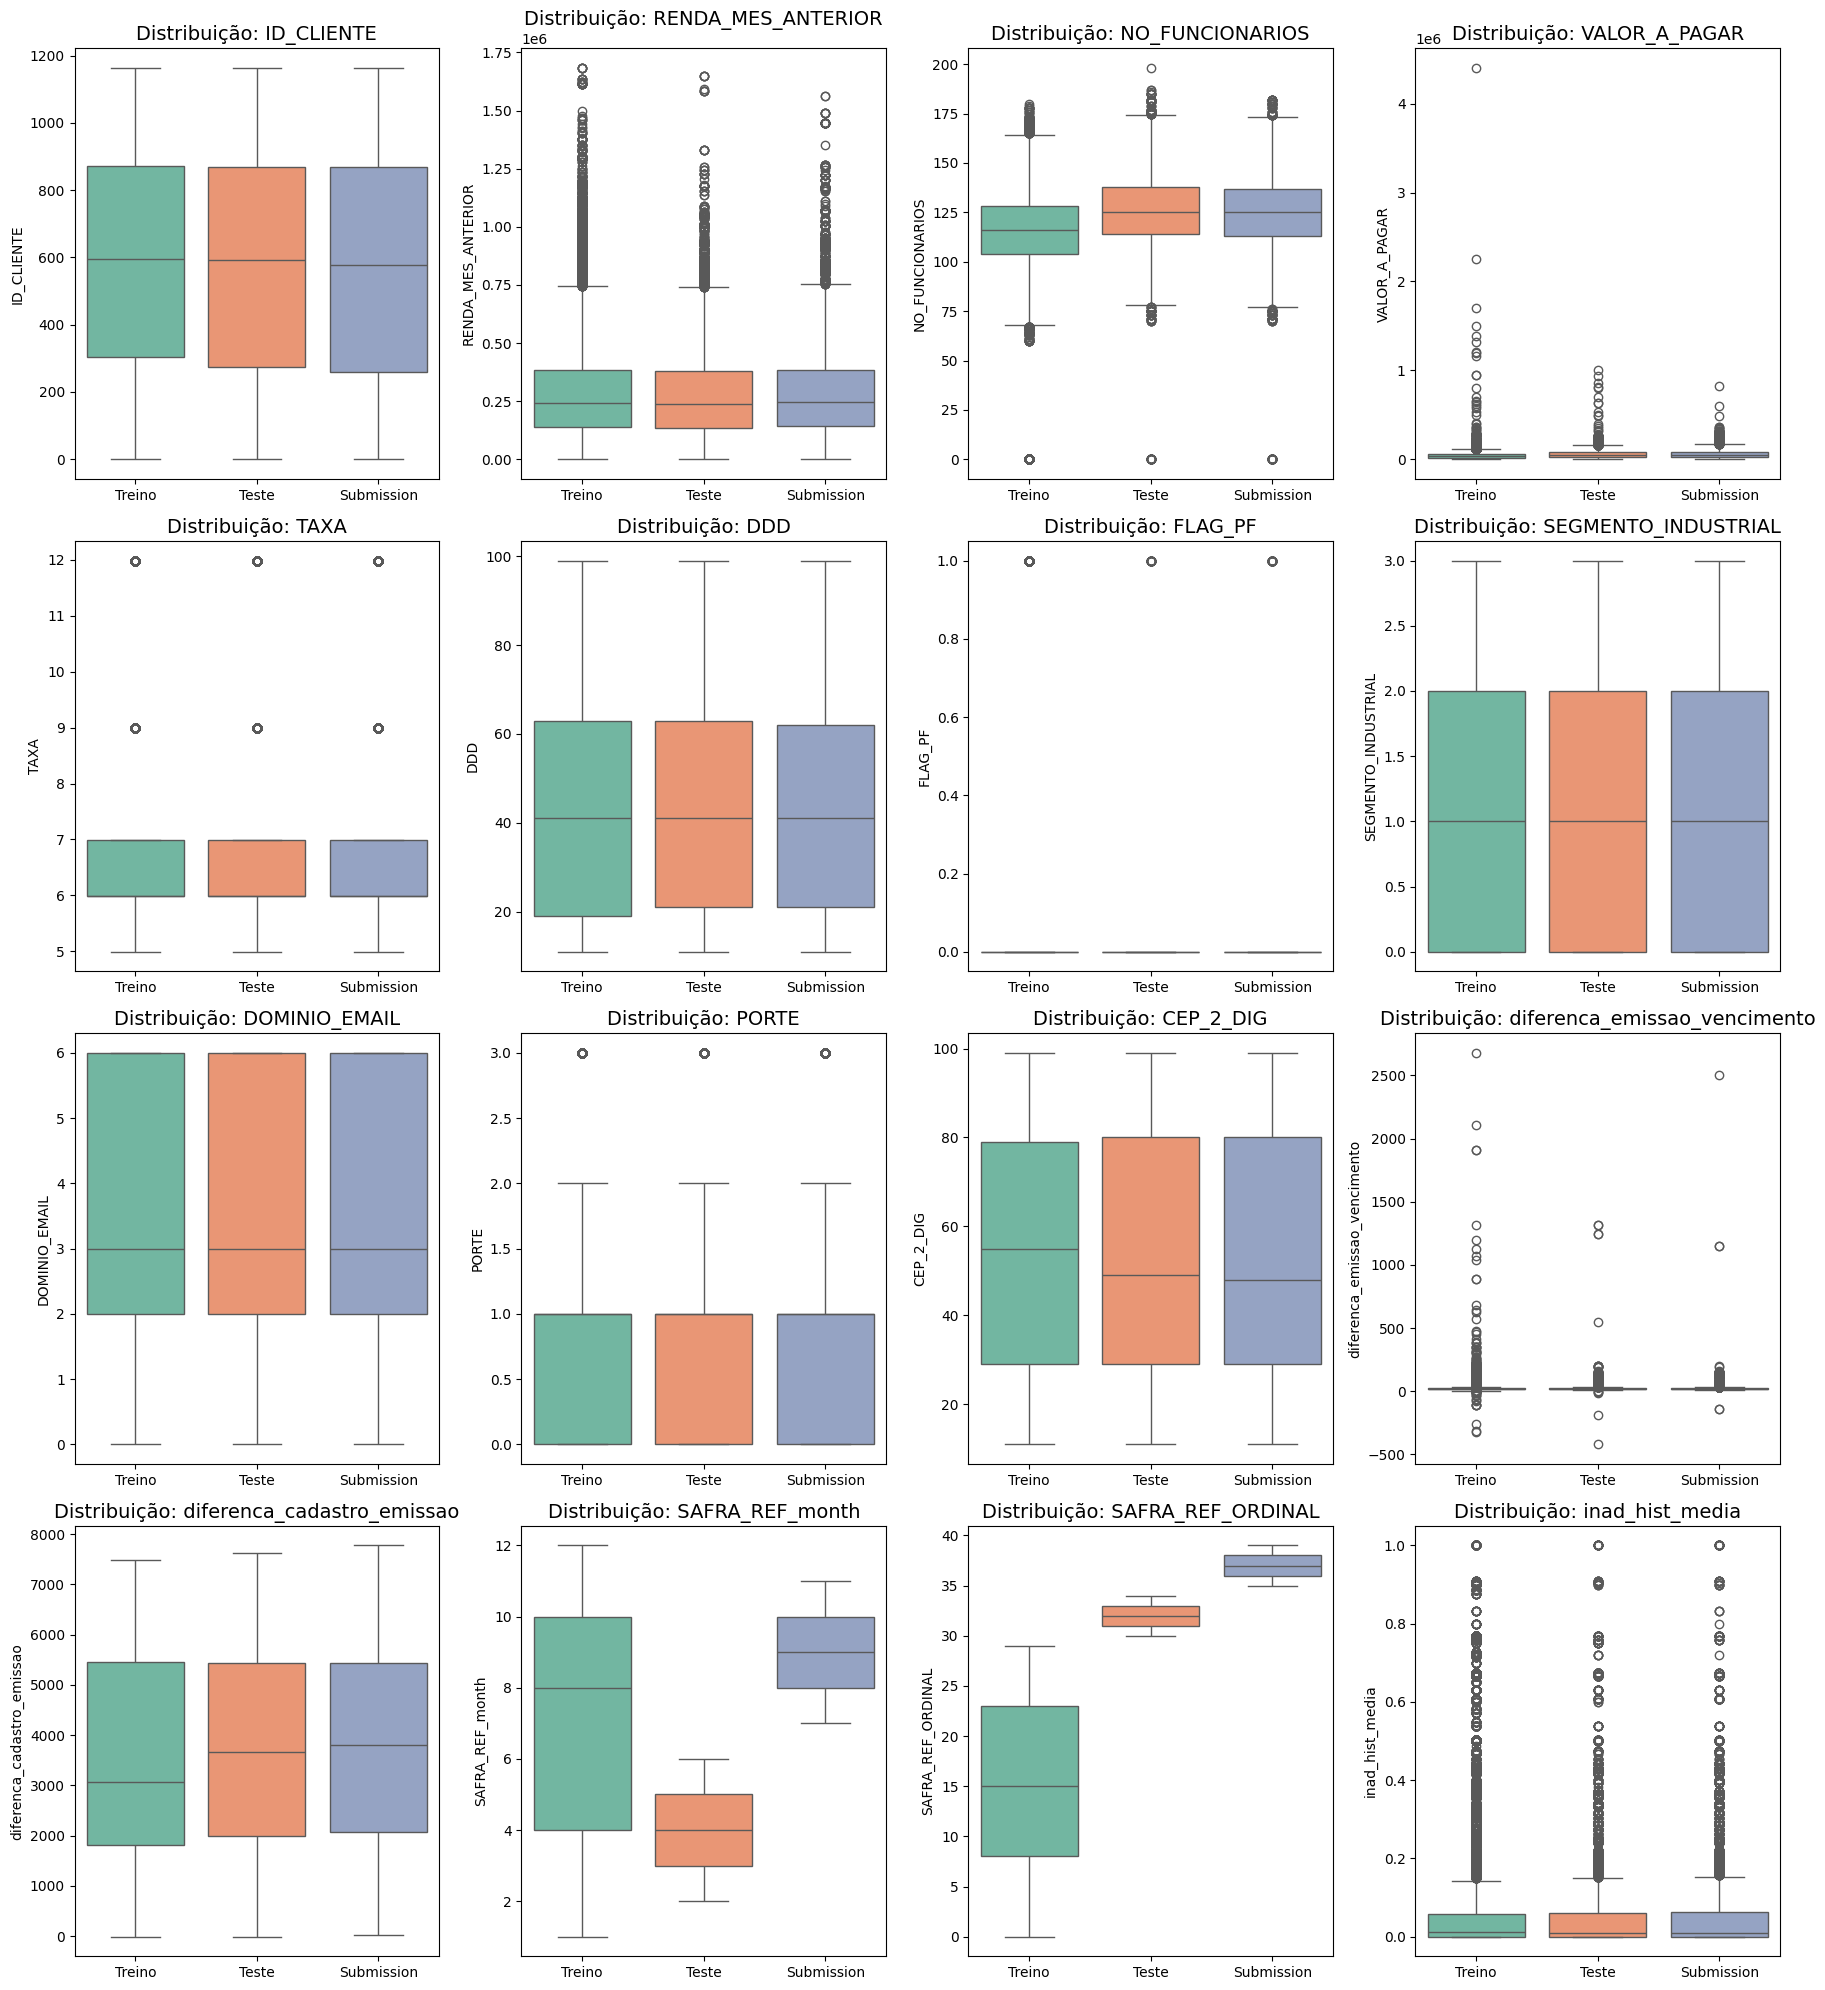

In [79]:
def plot_grid_numerica(train, test, sub):
    cols_num = train.select_dtypes(include=['number']).columns.tolist()
    ignored = ['INADIMPLENTE']
    cols_to_plot = [c for c in cols_num if c not in ignored]
    
    n_cols = 4
    n_rows = math.ceil(len(cols_to_plot) / n_cols)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 5))
    axes = axes.flatten() # Transforma a matriz em lista para iterar fácil

    for i, col in enumerate(cols_to_plot):
        df_comp = pd.concat([
            train[[col]].assign(Base='Treino'),
            test[[col]].assign(Base='Teste'),
            sub[[col]].assign(Base='Submission')
        ]).dropna()
        
        sns.boxplot(ax=axes[i], x='Base', y=col, data=df_comp, palette='Set2', hue='Base', legend=False)
        axes[i].set_title(f'Distribuição: {col}', fontsize=14)
        axes[i].set_xlabel('')
        
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

plot_grid_numerica(train_, test_, submission)

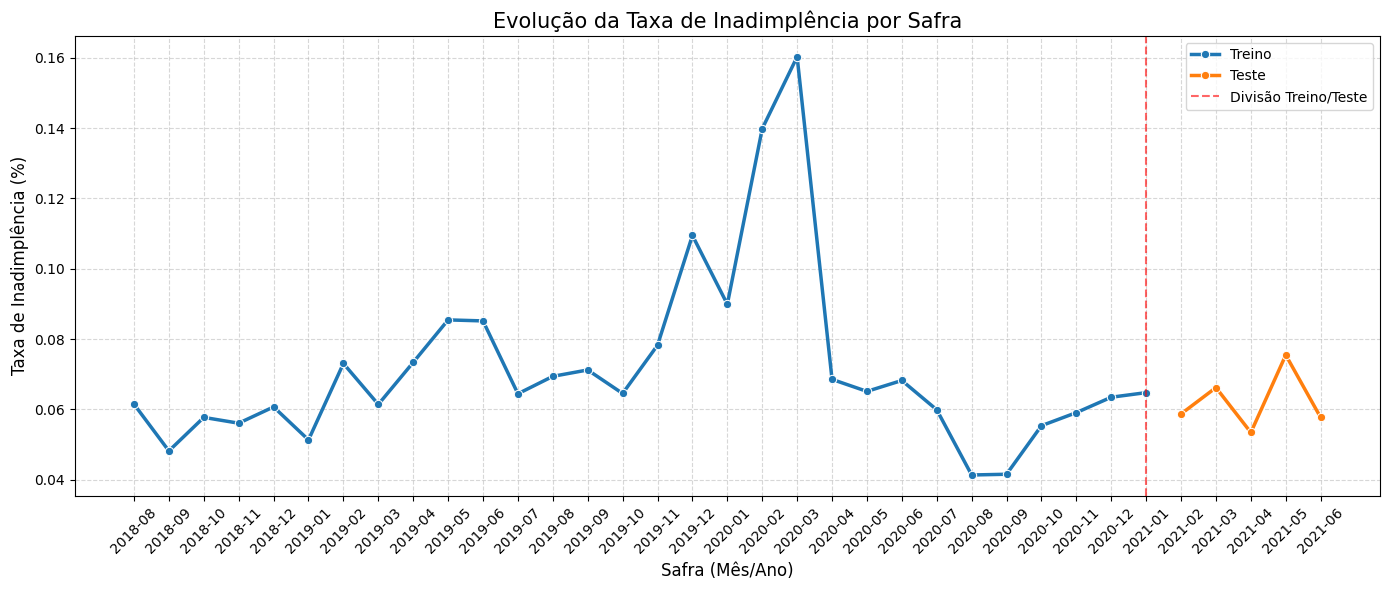

In [80]:
def plot_evolucao_inadimplencia(train, test, col_safra='SAFRA_REF', col_target='INADIMPLENTE'):
    evol_train = train.groupby(col_safra)[col_target].mean().reset_index()
    evol_train['Base'] = 'Treino'
    
    evol_test = test.groupby(col_safra)[col_target].mean().reset_index()
    evol_test['Base'] = 'Teste'
    
    evol_total = pd.concat([evol_train, evol_test])
    
    plt.figure(figsize=(14, 6))
    sns.lineplot(data=evol_total, x=col_safra, y=col_target, hue='Base', marker='o', linewidth=2.5)
    
    plt.axvline(x=evol_train[col_safra].iloc[-1], color='red', linestyle='--', alpha=0.6, label='Divisão Treino/Teste')
    
    plt.title('Evolução da Taxa de Inadimplência por Safra', fontsize=15)
    plt.ylabel('Taxa de Inadimplência (%)', fontsize=12)
    plt.xlabel('Safra (Mês/Ano)', fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_evolucao_inadimplencia(train, test)

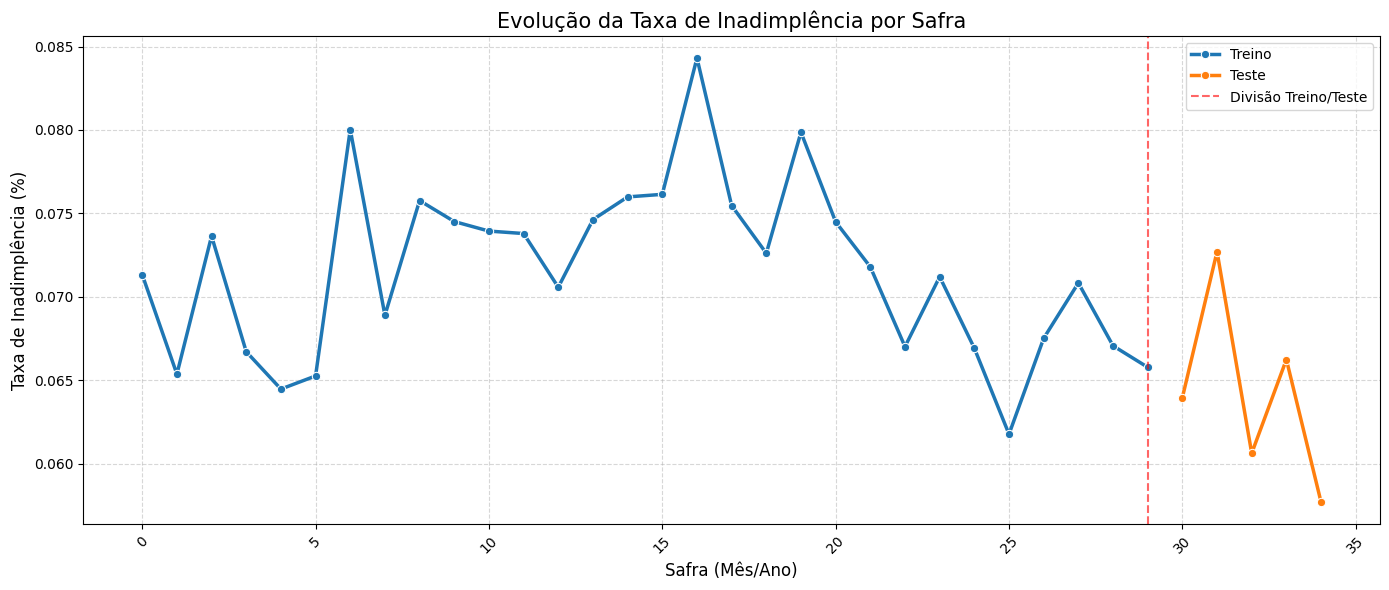

In [81]:
def plot_evolucao_inadimplencia(train, test, col_safra='SAFRA_REF', col_target='INADIMPLENTE'):
    evol_train = train.groupby(col_safra)[col_target].mean().reset_index()
    evol_train['Base'] = 'Treino'
    
    evol_test = test.groupby(col_safra)[col_target].mean().reset_index()
    evol_test['Base'] = 'Teste'
    
    evol_total = pd.concat([evol_train, evol_test])
    
    plt.figure(figsize=(14, 6))
    sns.lineplot(data=evol_total, x=col_safra, y=col_target, hue='Base', marker='o', linewidth=2.5)
    
    plt.axvline(x=evol_train[col_safra].iloc[-1], color='red', linestyle='--', alpha=0.6, label='Divisão Treino/Teste')
    
    plt.title('Evolução da Taxa de Inadimplência por Safra', fontsize=15)
    plt.ylabel('Taxa de Inadimplência (%)', fontsize=12)
    plt.xlabel('Safra (Mês/Ano)', fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_evolucao_inadimplencia(train_, test_, col_safra='SAFRA_REF_ORDINAL', col_target='inad_hist_media')

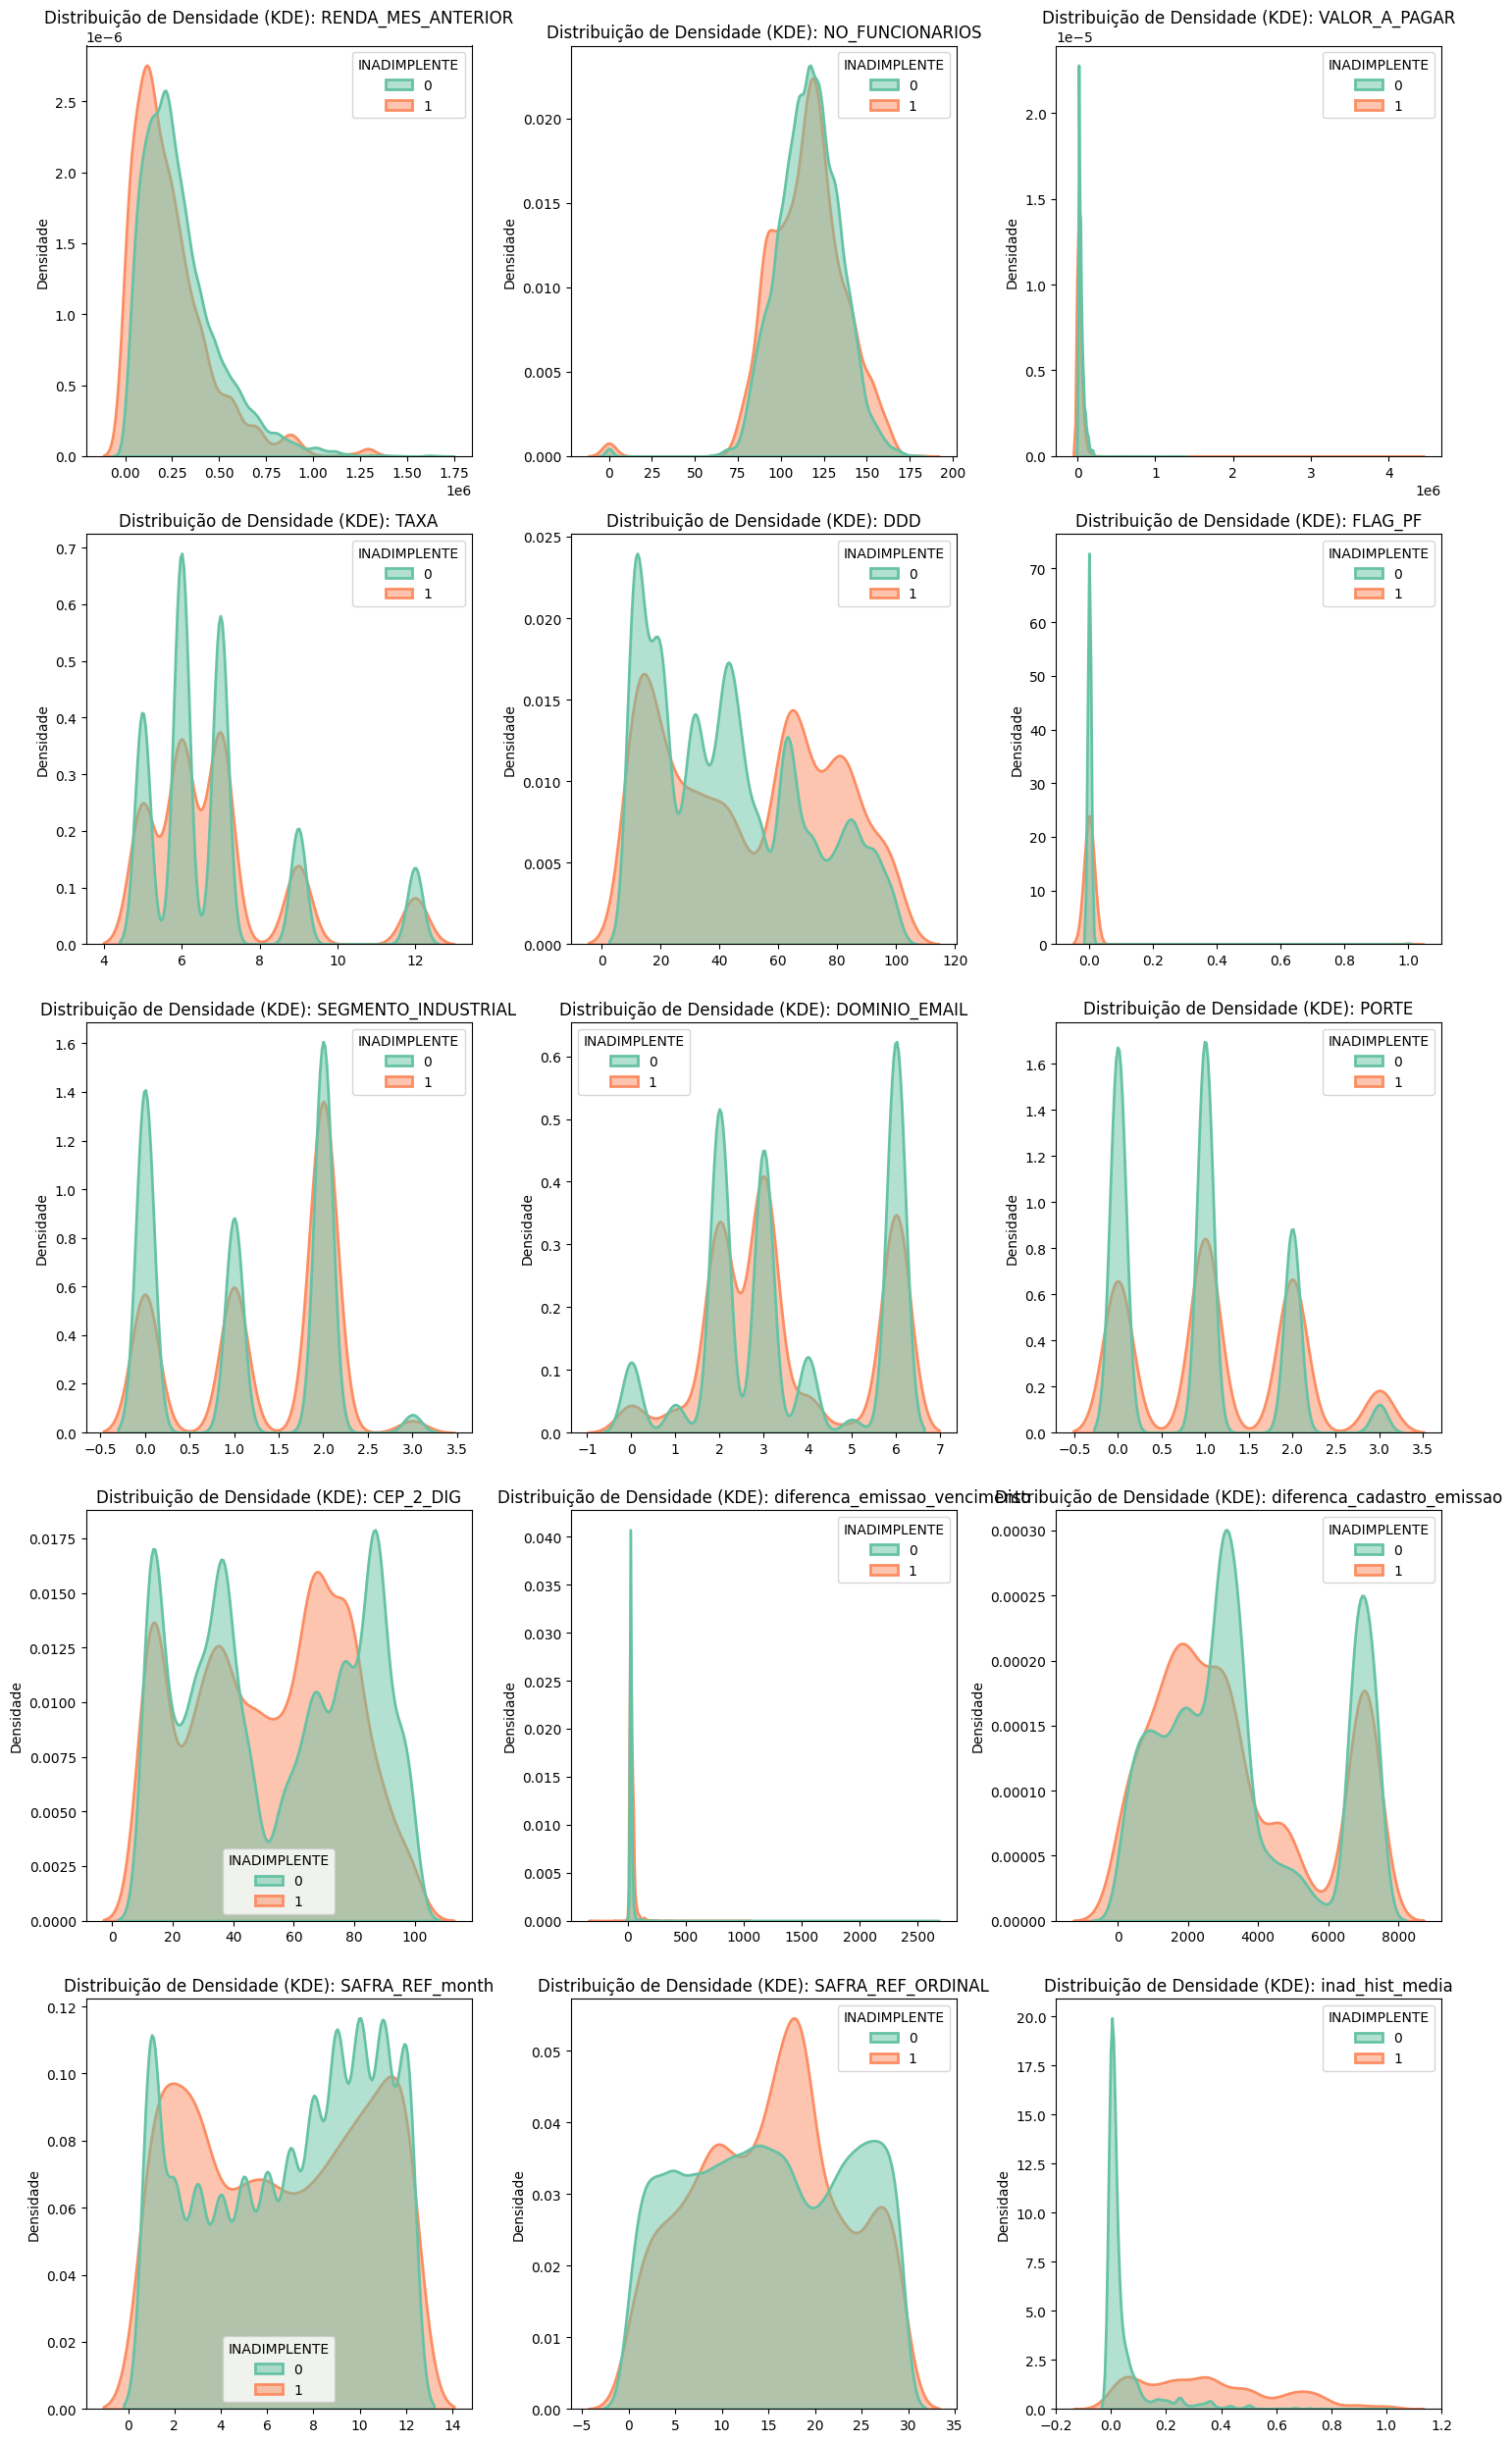

In [82]:
n_cols = 3

cols_num = train_.select_dtypes(include=['number']).columns.tolist()
ignored = ['ID_CLIENTE', 'INADIMPLENTE', 'MISSING']
target = "INADIMPLENTE"
cols_to_plot = [c for c in cols_num if c not in ignored]
n_rows = math.ceil(len(cols_to_plot) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    if col == target:
        continue

    sns.kdeplot(
        data=train_,
        x=col,
        hue=target,
        fill=True,       
        common_norm=False,
        palette="Set2",
        ax=axes[i],
        alpha=0.5,
        linewidth=2,
        warn_singular=False
    )
    axes[i].set_title(f'Distribuição de Densidade (KDE): {col}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Densidade')

# Remove eixos extras se houver
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [83]:
k=train_.groupby("ID_CLIENTE")["RENDA_MES_ANTERIOR"].diff()
display(k)

0             NaN
1             0.0
2             0.0
3             0.0
4             0.0
           ...   
65535         0.0
65536   -168487.0
65537         0.0
65538         0.0
65539    179414.0
Name: RENDA_MES_ANTERIOR, Length: 65540, dtype: float64

In [84]:
k = (
    train_.groupby("ID_CLIENTE")["VALOR_A_PAGAR"]
    .expanding()
    .mean()
    .shift(1)
    .reset_index(level=0, drop=True)
)
k

166                NaN
167      100616.100000
168       95084.450000
169       94743.900000
170       96729.450000
             ...      
64221     37831.037059
64222     37400.455233
64597     37362.009770
64598     37728.188068
64599     37771.892697
Name: VALOR_A_PAGAR, Length: 65540, dtype: float64

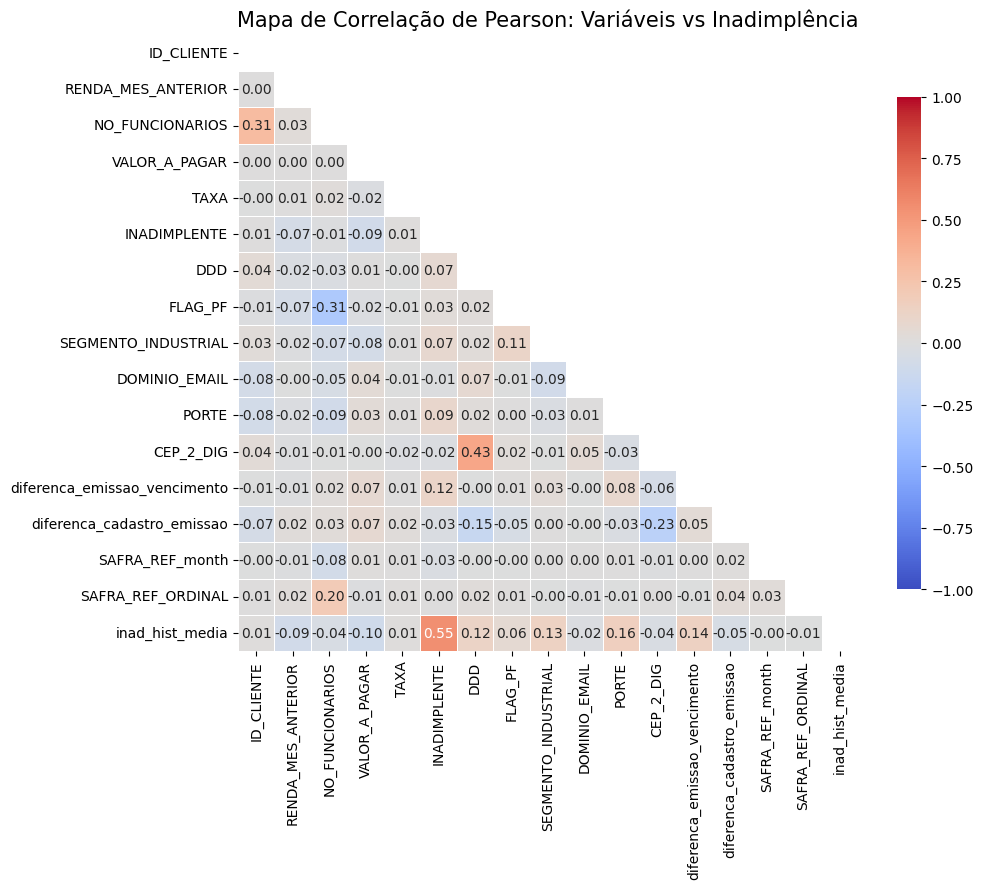

In [85]:
corr_matrix = train_[train_.columns].corr()

plt.figure(figsize=(10, 8))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Gerar o Heatmap
sns.heatmap(
    corr_matrix, 
    mask=mask, 
    annot=True,          
    fmt=".2f",           
    cmap='coolwarm',   
    vmin=-1, vmax=1,    
    center=0,
    linewidths=.5,
    cbar_kws={"shrink": .8}
)

plt.title('Mapa de Correlação de Pearson: Variáveis vs Inadimplência', fontsize=15)
plt.show()

## Feature Importance

In [86]:
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import MinMaxScaler

In [126]:
X_train = train_.drop(columns=[target])
y_train = train_[target]


def feature_importance_weighted(X: pd.DataFrame, y: pd.Series,
                                  w_rf=5, w_iso=2, w_mi=4,
                                  contamination=0.1, random_state=42):
    """
    Combina 3 métodos de importância de feature com pesos configuráveis.
    
    RF  → captura relações não-lineares e interações entre features
    ISO → penaliza features que isolam anomalias (útil para dados ruidosos)
    MI  → mede dependência estatística com o target (funciona com não-linearidades)
    """
    results = {}

    rf = RandomForestClassifier(n_estimators=200, random_state=random_state, n_jobs=-1)
    rf.fit(X, y)
    results["rf"] = rf.feature_importances_

    iso_scores = []
    for col in X.columns:
        iso = IsolationForest(contamination=contamination, random_state=random_state)
        iso.fit(X[[col]])
        # score_samples retorna negativo: inverte para "utilidade"
        score = -iso.score_samples(X[[col]]).mean()
        iso_scores.append(score)
    results["iso"] = np.array(iso_scores)

    results["mi"] = mutual_info_classif(X, y, random_state=random_state)

    scaler = MinMaxScaler()
    norm = {k: scaler.fit_transform(v.reshape(-1, 1)).ravel()
            for k, v in results.items()}

    total_w = w_rf + w_iso + w_mi
    combined = (norm["rf"] * w_rf + norm["iso"] * w_iso + norm["mi"] * w_mi) / total_w

    df_result = pd.DataFrame({
        "feature":   X.columns,
        "rf_score":  norm["rf"].round(3),
        "iso_score": norm["iso"].round(3),
        "mi_score":  norm["mi"].round(3),
        "final":     combined.round(3),
    }).sort_values("final", ascending=False).reset_index(drop=True)

    df_result.index += 1  # ranking começa em 1
    return df_result

df_scores = feature_importance_weighted(X_train, y_train, w_rf=5, w_iso=2, w_mi=4)
print(df_scores)
top_features = df_scores[df_scores["final"]>0.1]["feature"]

                         feature  rf_score  iso_score  mi_score  final
1                inad_hist_media     1.000      0.067     0.955  0.814
2                  VALOR_A_PAGAR     0.793      0.320     0.535  0.613
3             RENDA_MES_ANTERIOR     0.260      0.360     1.000  0.547
4     diferenca_cadastro_emissao     0.516      0.645     0.288  0.456
5   diferenca_emissao_vencimento     0.402      0.000     0.383  0.322
6                      CEP_2_DIG     0.131      0.868     0.283  0.320
7                            DDD     0.146      0.889     0.205  0.302
8              SAFRA_REF_ORDINAL     0.210      1.000     0.037  0.291
9                SAFRA_REF_month     0.156      0.983     0.031  0.261
10               NO_FUNCIONARIOS     0.216      0.384     0.101  0.205
11                          TAXA     0.119      0.687     0.024  0.188
12                         PORTE     0.061      0.686     0.077  0.181
13           SEGMENTO_INDUSTRIAL     0.048      0.645     0.098  0.175
14    

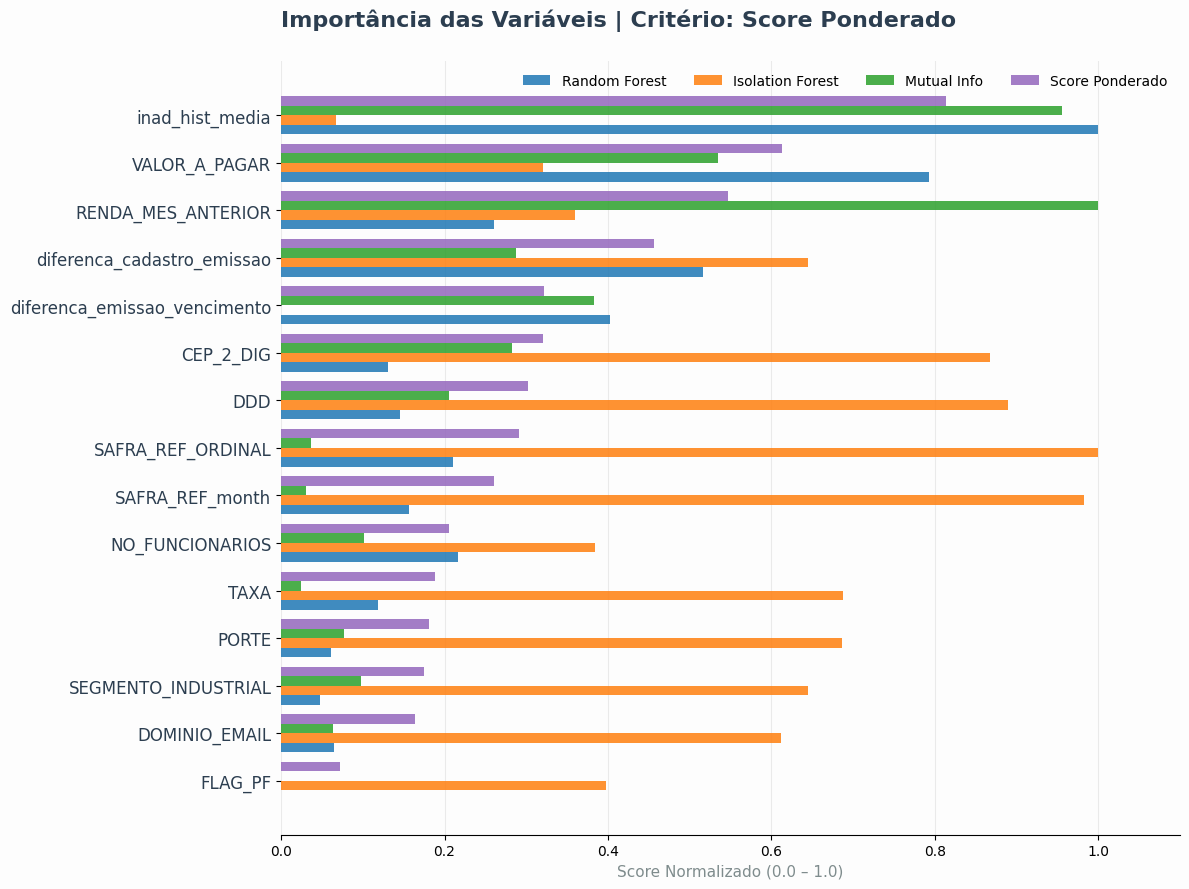

In [127]:
from matplotlib import colormaps

def plot_feature_importance(df: pd.DataFrame,
                             view="all", sort_by="final",
                             top_n: int = None,
                             figsize=(12, 9)) -> None:
    
    cmap = colormaps.get_cmap('tab10') 
    
    col_map = {
        "rf":    ("rf_score",  cmap(0), "Random Forest"),
        "iso":   ("iso_score", cmap(1), "Isolation Forest"),
        "mi":    ("mi_score",  cmap(2), "Mutual Info"),
        "final": ("final",     cmap(4), "Score Ponderado"), 
    }
    
    cols = list(col_map.keys()) if view == "all" else [view]

    # Ordenação e Filtragem
    sort_col = col_map[sort_by][0] if sort_by in col_map else sort_by
    df_plot = df.sort_values(sort_col, ascending=True)

    if top_n:
        df_plot = df_plot.tail(top_n)

    n_feat = len(df_plot)
    n_cols = len(cols)
    bar_h  = 0.8 / n_cols
    y_pos  = np.arange(n_feat)
    offsets = np.linspace(-(n_cols - 1) / 2, (n_cols - 1) / 2, n_cols) * bar_h

    fig, ax = plt.subplots(figsize=figsize, facecolor='#FDFDFD')
    ax.set_facecolor('#FDFDFD')

    for offset, key in zip(offsets, cols):
        col, color, label = col_map[key]
        bars = ax.barh(y_pos + offset, df_plot[col], height=bar_h,
                      color=color, label=label, edgecolor='none', alpha=0.85)
        
        # Adiciona rótulos de valores se estiver vendo apenas uma métrica (ex: final)
        if n_cols == 1:
            for bar in bars:
                width = bar.get_width()
                ax.text(width + 0.01, bar.get_y() + bar.get_height()/2, 
                        f'{width:.2f}', va='center', fontsize=10, fontweight='bold', color=color)

    # Estilização de Eixos e Títulos
    ax.set_yticks(y_pos)
    ax.set_yticklabels(df_plot["feature"], fontsize=12, color='#2C3E50')
    
    ax.set_title(f"Importância das Variáveis | Critério: {col_map[sort_by][2]}", 
                 loc='left', fontsize=16, fontweight='bold', pad=25, color='#2C3E50')
    
    ax.set_xlabel("Score Normalizado (0.0 – 1.0)", fontsize=11, color='#7F8C8D')
    ax.set_xlim(0, 1.1) # Espaço extra para as labels
    
    # Grade e Limpeza
    ax.xaxis.grid(True, linestyle='-', alpha=0.15, color='gray')
    ax.set_axisbelow(True)
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)

    ax.legend(loc="upper right", frameon=False, fontsize=10, ncol=n_cols)

    plt.tight_layout()
    plt.show()

# Chamada com o mapa de cores nativo aplicado
plot_feature_importance(df_scores, view="all", sort_by="final", top_n=15)

## Modelo

In [128]:
features_selecionadas = top_features.tolist()
features_selecionadas

['inad_hist_media',
 'VALOR_A_PAGAR',
 'RENDA_MES_ANTERIOR',
 'diferenca_cadastro_emissao',
 'diferenca_emissao_vencimento',
 'CEP_2_DIG',
 'DDD',
 'SAFRA_REF_ORDINAL',
 'SAFRA_REF_month',
 'NO_FUNCIONARIOS',
 'TAXA',
 'PORTE',
 'SEGMENTO_INDUSTRIAL',
 'DOMINIO_EMAIL']

In [129]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import StandardScaler

from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, classification_report
import pandas as pd

features_selecionadas = top_features.tolist()

X_train_final = train_[features_selecionadas]
y_train_final = train_[target]

X_test_final = test_[features_selecionadas]
y_test_final = test_[target]

In [130]:
modelo_lr = Pipeline([
    ("scaler", MinMaxScaler()),
    ("lr", LogisticRegression(max_iter=300, random_state=42))
])

mlp_model = Pipeline([
    ("scaler", MinMaxScaler()),
    ("mlp", MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=300, random_state=42))
])

In [ ]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

from sklearn.metrics import (roc_auc_score, f1_score, precision_score, recall_score, accuracy_score, brier_score_loss)
from sklearn.model_selection import cross_validate


from sklearn.pipeline import Pipeline 
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.base import clone


def comparar_modelos(X_train, y_train, X_test, y_test):
    X_train = X_train.astype(float)
    X_test  = X_test.astype(float)
    y_train = y_train.astype(int)
    y_test  = y_test.astype(int)

    modelos = {
        "Regressão Logística":  modelo_lr,
        "Random Forest":        RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1),
        "Gradient Boosting":    GradientBoostingClassifier(n_estimators=100, random_state=42),
        "XGBoost":              XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=6, random_state=42),
        #"Redes Neurais":        mlp_model,
        "KNN":                  KNeighborsClassifier( n_neighbors=10),
        "Decision Tree":        DecisionTreeClassifier(random_state=42),
    }

    scoring = ["accuracy", "recall", "precision", "f1", "roc_auc"]
    lista_resultados = []
    predictions = {}
    probabilidades_modelos={}

    for nome, model in modelos.items():
        print(f"Treinando e avaliando: {nome}...")

        pipeline = ImbPipeline([
            ("smote", SMOTE(random_state=42)),
            ("model", model),
        ])

        cv_results = cross_validate( pipeline, X_train, y_train, cv=5, scoring=scoring, return_train_score=False, n_jobs=-1,)

        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)
        predictions[nome] = y_pred

        if hasattr(pipeline.named_steps["model"], "predict_proba"):
            y_proba = pipeline.predict_proba(X_test)[:, 1]
        else:
            y_proba = y_pred  # fallback para modelos sem predict_proba
        
        probabilidades_modelos[nome]=y_proba

        metricas = {
            "Modelo": nome,

            "CV Acurácia":  cv_results["test_accuracy"].mean(),
            "CV Recall":    cv_results["test_recall"].mean(),
            "CV Precision": cv_results["test_precision"].mean(),
            "CV F1":        cv_results["test_f1"].mean(),
            "CV AUC":       cv_results["test_roc_auc"].mean(),

  
            "Teste Acurácia":  accuracy_score(y_test, y_pred),
            "Teste Recall":    recall_score(y_test, y_pred),
            "Teste Precision": precision_score(y_test, y_pred),
            "Teste F1":        f1_score(y_test, y_pred),
            "Teste AUC":       roc_auc_score(y_test, y_proba),
        }

        lista_resultados.append(metricas)

    df_resultados = (
        pd.DataFrame(lista_resultados)
        .set_index("Modelo")
        .sort_values(by="Teste AUC", ascending=False)
    )

    return df_resultados, probabilidades_modelos, predictions


resultados_modelos, probabilidades_modelos, predicoes_modelos = comparar_modelos( X_train_final, y_train_final, X_test_final, y_test_final)
display(resultados_modelos)

Treinando e avaliando: Regressão Logística...


Treinando e avaliando: Random Forest...
Treinando e avaliando: Gradient Boosting...
Treinando e avaliando: XGBoost...
Treinando e avaliando: KNN...
Treinando e avaliando: Decision Tree...


,CV Acurácia,CV Recall,CV Precision,CV F1,CV AUC,Teste Acurácia,Teste Recall,Teste Precision,Teste F1,Teste AUC
Modelo,,,,,,,,,,
Random Forest,0.910009,0.511220,0.594494,0.375753,0.917006,0.914856,0.737197,0.401321,0.519715,0.922243
XGBoost,0.898047,0.521473,0.516774,0.371796,0.914115,0.938100,0.530997,0.504481,0.517400,0.908932
Gradient Boosting,0.904333,0.522922,0.579587,0.357837,0.921639,0.915109,0.696765,0.397692,0.506366,0.906077
Regressão Logística,0.888679,0.739656,0.361695,0.485368,0.908006,0.883274,0.638814,0.297739,0.406170,0.873442
KNN,0.796323,0.469538,0.168607,0.248095,0.678350,0.789877,0.455526,0.139152,0.213182,0.689184
Decision Tree,0.852624,0.367253,0.316412,0.271568,0.628733,0.839987,0.374663,0.162194,0.226384,0.623055


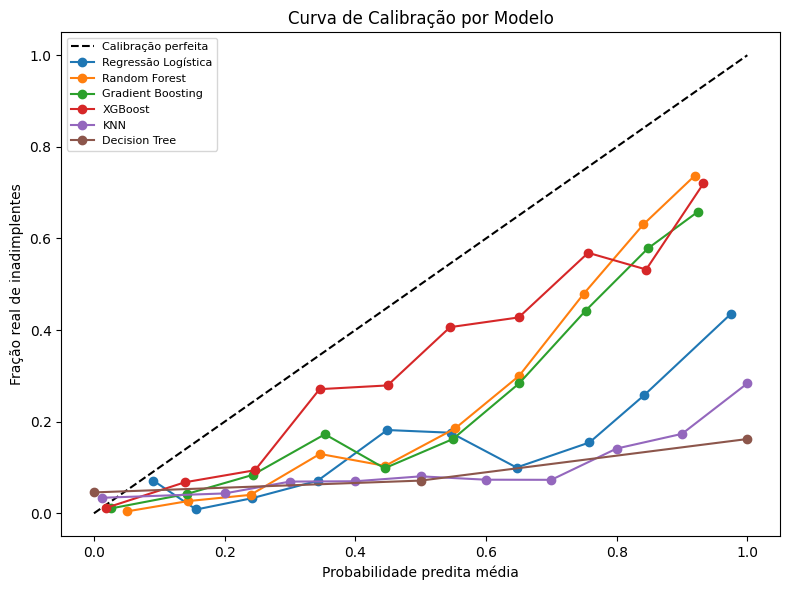

In [132]:
def plot_calibracao(y_test, probabilidades):
    _, ax = plt.subplots(figsize=(8, 6))
    ax.plot([0, 1], [0, 1], "k--", label="Calibração perfeita")

    for nome, y_proba in probabilidades.items():
        frac_pos, mean_pred = calibration_curve(y_test, y_proba, n_bins=10)
        ax.plot(mean_pred, frac_pos, marker="o", label=nome)

    ax.set_xlabel("Probabilidade predita média")
    ax.set_ylabel("Fração real de inadimplentes")
    ax.set_title("Curva de Calibração por Modelo")
    ax.legend(loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.show()

plot_calibracao(y_test_final, probabilidades_modelos)


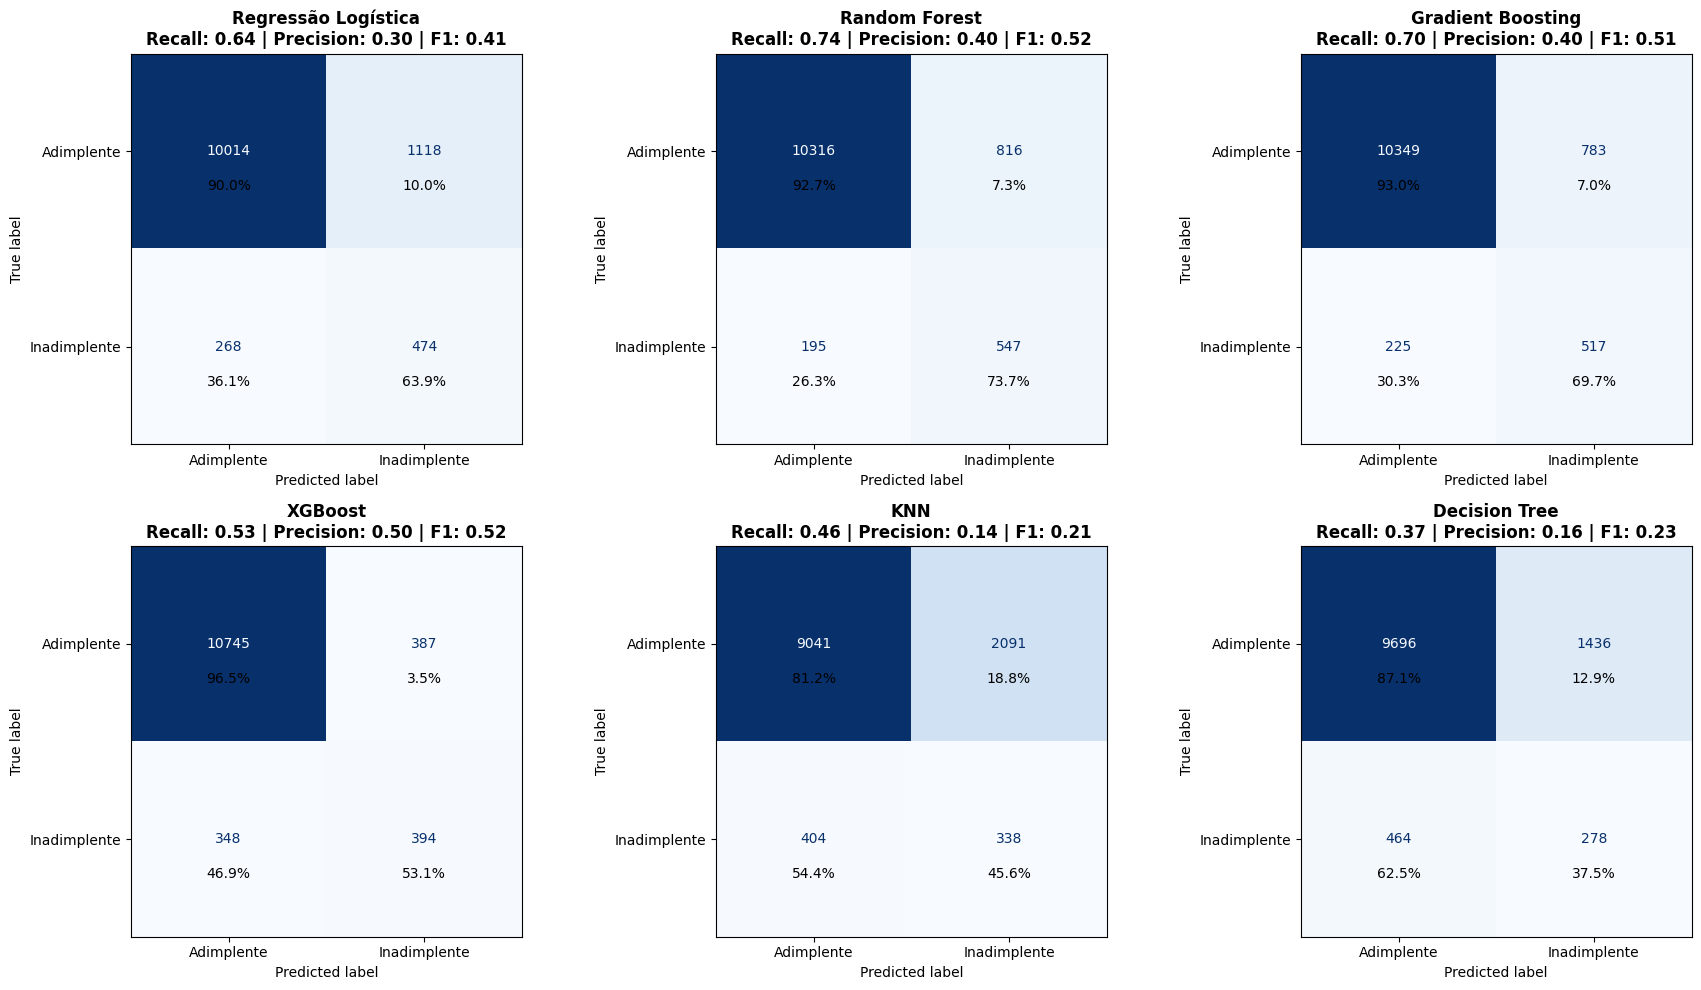

In [133]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

def plot_confusion_matrices(predicoes_modelos, y_test, cols=3, figsize_width=18, figsize_height_per_row=5, cmap='Blues', labels=['Adimplente', 'Inadimplente']):

    n_modelos = len(predicoes_modelos)
    rows = math.ceil(n_modelos / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(figsize_width, rows * figsize_height_per_row))
    axes = axes.flatten()

    for i, (nome, y_pred) in enumerate(predicoes_modelos.items()):
        cm = confusion_matrix(y_test, y_pred)
        cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

        recall = recall_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)

        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
        disp.plot(ax=axes[i], cmap=cmap, values_format='d', colorbar=False)

        for j in range(cm.shape[0]):
            for k in range(cm.shape[1]):
                axes[i].text(
                    k, j + 0.2,
                    f"{cm_norm[j, k]:.1%}",
                    ha="center",
                    color="black",
                    fontsize=10
                )

        axes[i].set_title(
            f"{nome}\nRecall: {recall:.2f} | Precision: {precision:.2f} | F1: {f1:.2f}",
            fontsize=12,
            fontweight='bold'
        )

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

plot_confusion_matrices(predicoes_modelos, y_test_final)

In [134]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")


scale = (y_train_final == 0).sum() / (y_train_final == 1).sum()

modelos = {
    "Regressão Logística": LogisticRegression(class_weight="balanced", max_iter=300, random_state=42),
    "Random Forest":       RandomForestClassifier(class_weight="balanced", n_estimators=200, max_depth=10, random_state=42, n_jobs=-1),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=100, random_state=42),
    "XGBoost":             XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=6, scale_pos_weight=scale, random_state=42, tree_method="hist"),
    "Decision Tree":       DecisionTreeClassifier(class_weight="balanced", random_state=42),
}

scoring = ["accuracy", "recall", "precision", "f1", "roc_auc"]


def comparar_modelos(X_train, y_train, X_test, y_test):
    X_train = X_train.astype(float)
    X_test  = X_test.astype(float)
    y_train = y_train.astype(int)
    y_test  = y_test.astype(int)

    lista_resultados = []
    probabilidades   = {}
    predictions      = {}
    modelos_treinados = {}

    for nome, model in modelos.items():
        print(f"Treinando: {nome}...")

        pipeline = Pipeline([("model", model)])

        # 1. CV para métricas de generalização
        cv_results = cross_validate(
            pipeline, X_train, y_train,
            cv=5, scoring=scoring,
            return_train_score=False,
            n_jobs=-1,
        )

        # 2. Calibração (treina internamente — não precisa de pipeline.fit antes)
        calibrated = CalibratedClassifierCV(
            estimator=clone(pipeline),
            method="isotonic",
            cv=5,
        )
        calibrated.fit(X_train, y_train)
        modelos_treinados[nome] = calibrated

        # 3. Probabilidades calibradas
        y_proba_cal = calibrated.predict_proba(X_test)[:, 1]
        y_pred      = (y_proba_cal >= 0.3).astype(int)

        probabilidades[nome] = y_proba_cal
        predictions[nome]    = y_pred

        metricas = {
            "Modelo": nome,

            "CV Acurácia":  cv_results["test_accuracy"].mean(),
            "CV Recall":    cv_results["test_recall"].mean(),
            "CV Precision": cv_results["test_precision"].mean(),
            "CV F1":        cv_results["test_f1"].mean(),
            "CV AUC":       cv_results["test_roc_auc"].mean(),

            "Teste Acurácia":  accuracy_score(y_test, y_pred),
            "Teste Recall":    recall_score(y_test, y_pred),
            "Teste Precision": precision_score(y_test, y_pred),
            "Teste F1":        f1_score(y_test, y_pred),
            "Teste AUC":       roc_auc_score(y_test, y_proba_cal),
            "Brier Score":     brier_score_loss(y_test, y_proba_cal),
        }
        lista_resultados.append(metricas)

    df_resultados = (
        pd.DataFrame(lista_resultados)
        .set_index("Modelo")
        .sort_values(by="Teste AUC", ascending=False)
    )

    return df_resultados, probabilidades, predictions, modelos_treinados


resultados_modelos, probabilidades_modelos, predictions_modelos, modelos_treinados = comparar_modelos( X_train_final, y_train_final, X_test_final, y_test_final)
display(resultados_modelos)

Treinando: Regressão Logística...
Treinando: Random Forest...
Treinando: Gradient Boosting...
Treinando: XGBoost...
Treinando: Decision Tree...


,CV Acurácia,CV Recall,CV Precision,CV F1,CV AUC,Teste Acurácia,Teste Recall,Teste Precision,Teste F1,Teste AUC,Brier Score
Modelo,,,,,,,,,,,
XGBoost,0.885307,0.531671,0.553628,0.342786,0.913616,0.930689,0.615903,0.459296,0.526195,0.917825,0.046703
Random Forest,0.908056,0.502474,0.599389,0.359643,0.909989,0.920246,0.696765,0.417272,0.521959,0.915243,0.043717
Gradient Boosting,0.932316,0.302264,0.705869,0.345821,0.921193,0.919909,0.688679,0.415110,0.517993,0.913777,0.041431
Regressão Logística,0.701663,0.685767,0.152563,0.249307,0.754042,0.920835,0.257412,0.329310,0.288956,0.781430,0.053968
Decision Tree,0.912664,0.283957,0.381526,0.297609,0.622586,0.941721,0.140162,0.658228,0.231111,0.753762,0.051442


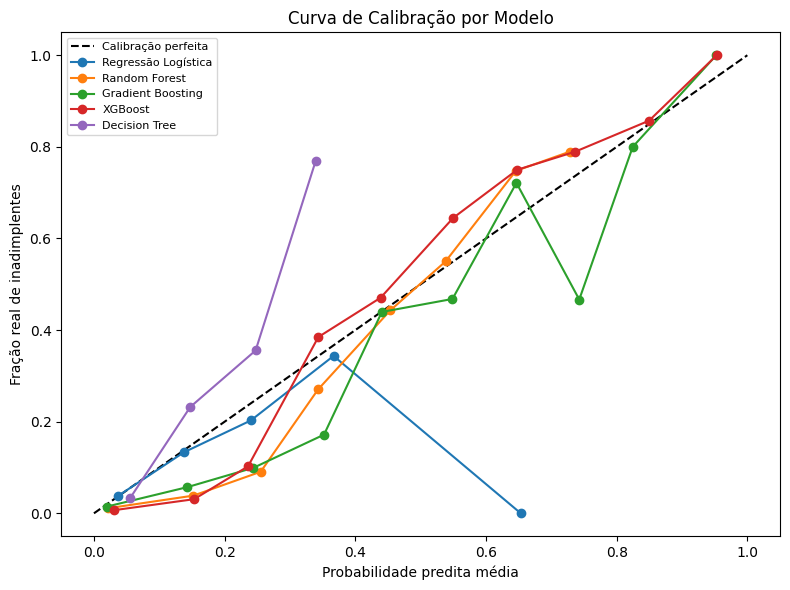

In [110]:

plot_calibracao(y_test_final, probabilidades_modelos)

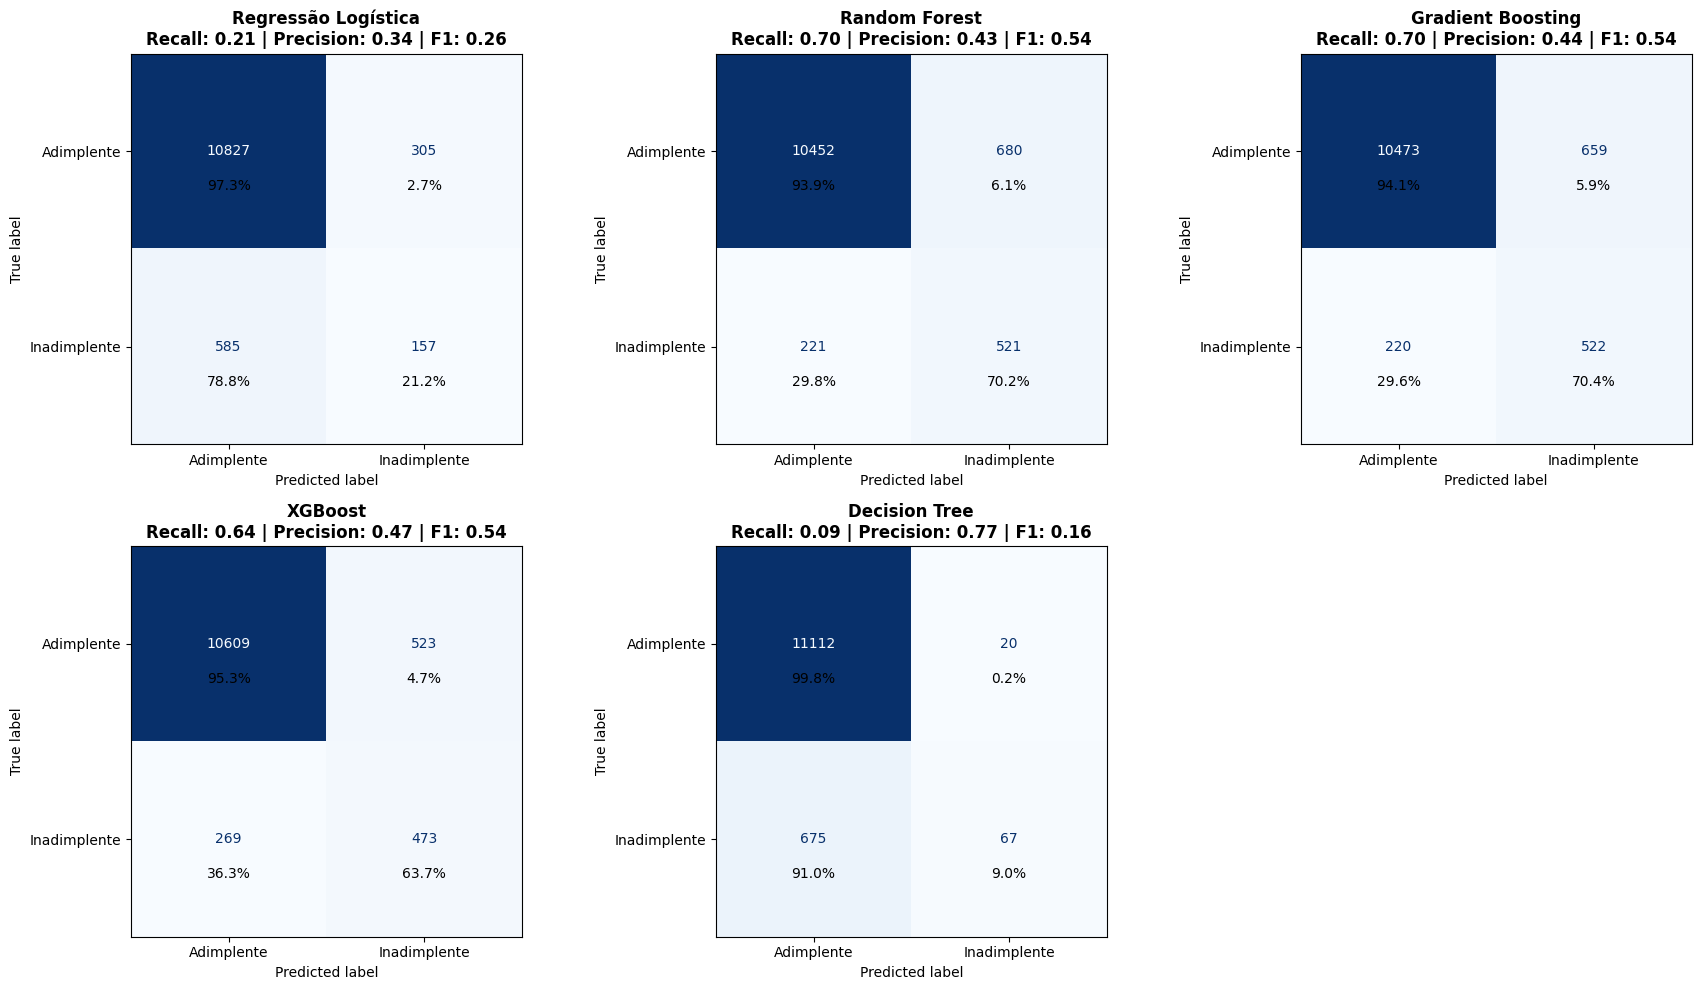

In [102]:
plot_confusion_matrices(predictions_modelos, y_test_final)

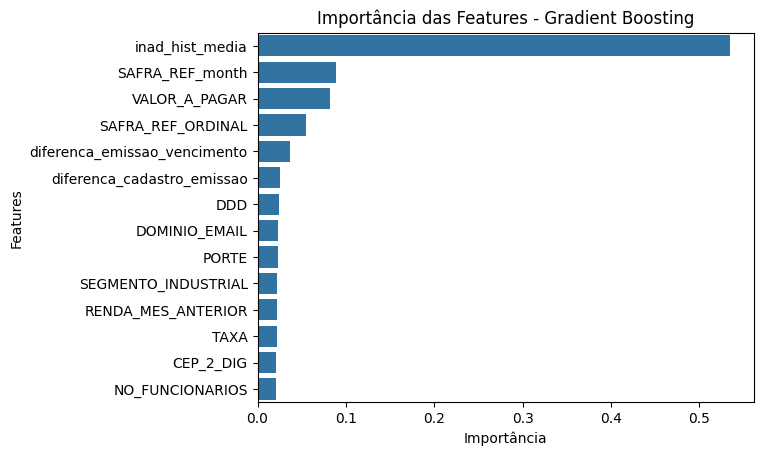

In [135]:
df = pd.DataFrame(data=modelos_treinados["XGBoost"].calibrated_classifiers_[0].estimator.named_steps["model"].feature_importances_, 
                 index=features_selecionadas, 
                 columns=["Importance"])

df = df.sort_values(by="Importance", ascending=False)

a=sns.barplot(x=df["Importance"], y=df.index)
a.set_title("Importância das Features - Gradient Boosting")
a.set_xlabel("Importância")
a.set_ylabel("Features")
plt.show()

In [104]:
def tabela_risco(X_test, y_test, probabilidades, modelo="Random Forest"):
    y_proba = probabilidades[modelo]

    def faixa(p):
        if p < 0.20:   return "🟢 Baixo"
        elif p < 0.50: return "🟡 Moderado"
        elif p < 0.75: return "🔴 Alto"
        else:          return "⛔ Muito alto"

    df = pd.DataFrame({
        "prob_inadimplencia": y_proba,
        "faixa_risco":        [faixa(p) for p in y_proba],
        "inadimpliu":         y_test.values,
        "residuo":            y_proba - y_test.values,   # positivo = superestimou, negativo = subestimou
        "acertou":            ((y_proba >= 0.5).astype(int) == y_test.values),
    }, index=X_test.index)

    df["acertou"] = df["acertou"].map({True: "✅", False: "❌"})

    return df.sort_values("prob_inadimplencia", ascending=False)


df_risco = tabela_risco(X_test_final, y_test_final, probabilidades_modelos, modelo="Random Forest")
display(df_risco)

,prob_inadimplencia,faixa_risco,inadimpliu,residuo,acertou
10613,0.758980,⛔ Muito alto,0,0.758980,❌
393,0.755099,⛔ Muito alto,1,-0.244901,✅
9933,0.751837,⛔ Muito alto,1,-0.248163,✅
272,0.751837,⛔ Muito alto,1,-0.248163,✅
3392,0.750382,⛔ Muito alto,1,-0.249618,✅
...,...,...,...,...,...
63,0.000899,🟢 Baixo,0,0.000899,✅
2459,0.000899,🟢 Baixo,0,0.000899,✅
2460,0.000899,🟢 Baixo,0,0.000899,✅
2462,0.000899,🟢 Baixo,0,0.000899,✅


## Escolha do modelo, métodos de tomada de decisão

### Análise de Decisão Multicritério (AHP)
- **Cálculo de Pesos:** Implementa o método da média geométrica para determinar o peso de importância de cada critério na matriz de comparação paritária.
- **Validação de Consistência:** Calcula a Razão de Consistência ($CR$) para garantir que as decisões do especialista não sejam aleatórias ou contraditórias.
- **Conformidade Matemática:** Utiliza o maior autovalor ($\lambda_{max}$) e o Índice Aleatório ($RI$) para validar a robustez lógica das prioridades atribuídas.

In [99]:
def ahp_weights(matrix):
    geom_mean = np.prod(matrix, axis=1)**(1/matrix.shape[0])
    return geom_mean / geom_mean.sum()

def consistency_ratio(matrix):
    eigvals = np.linalg.eigvals(matrix)
    lambda_max = np.max(eigvals.real)
    n = matrix.shape[0]
    CI = (lambda_max - n) / (n - 1)

    RI = {1:0, 2:0, 3:0.58, 4:0.90, 5:1.12, 6:1.24}
    return CI / RI[n]


### Priorização de Critérios e Normalização (AHP)
- **Matriz de Decisão:** Define pesos para as métricas via AHP, priorizando **Recall** e **AUC** como fatores críticos para o negócio (detecção de churn).
- **Validação Lógica:** Calcula a Razão de Consistência ($CR$) para assegurar que as preferências atribuídas na matriz paritária são matematicamente coerentes. (CR<0.1)
- **Normalização de Performance:** Aplica escala *Min-Max* nos resultados dos modelos, preparando as métricas para a decisão final baseada nos pesos calculados.

In [141]:
criteria = ['Acurácia', 'Recall', 'Precision', 'F1', 'AUC']

A = np.array([
    [1,   1/5, 1/3, 1/5, 1/7],  # Acurácia
    [5,   1,   4,   3,   1],    # Recall
    [3,   1/4, 1,   1/3, 1/3],  # Precision
    [5,   1/3, 3,   1,   1/2],  # F1
    [7,   1,   3,   2,   1],    # AUC
])

weights = ahp_weights(A)
CR = consistency_ratio(A)

print(weights, CR)

get_columns=[]
for i in resultados_modelos.columns:
    if(i.startswith("Teste")):
        get_columns.append(i)

df_=resultados_modelos[get_columns]

df_norm = (df_ - df_.min()) / (df_.max() - df_.min())
df_norm

[0.0441298  0.35026288 0.09395667 0.1855034  0.32614725] 0.036530984596495494


,Teste Acurácia,Teste Recall,Teste Precision,Teste F1,Teste AUC
Modelo,,,,,
XGBoost,0.494208,0.854722,0.395194,1.000000,1.000000
Random Forest,0.015444,1.000000,0.267428,0.985645,0.984261
Gradient Boosting,0.000000,0.985472,0.260854,0.972206,0.975324
Regressão Logística,0.042471,0.210654,0.000000,0.196029,0.168644
Decision Tree,1.000000,0.000000,1.000000,0.000000,0.000000


### Ranking Final via Decisão Multicritério (AHP)
- **Cálculo do Score:** Realiza a multiplicação matricial entre as métricas normalizadas e os pesos derivados do AHP para gerar uma pontuação única por modelo.
- **Seleção do Campeão:** Ordena os modelos pelo `Score_AHP`, que reflete o melhor equilíbrio entre os objetivos de negócio (ex: priorização de Recall vs. Precisão).
- **Decisão Final:** Consolida o processo de escolha do algoritmo ideal, baseando-se em evidências estatísticas e prioridades estratégicas pré-definidas.

In [142]:
final_scores = df_norm.values @ weights
df_['Score_AHP'] = final_scores

df_=df_.sort_values('Score_AHP', ascending=False)
df_


,Teste Acurácia,Teste Recall,Teste Precision,Teste F1,Teste AUC,Score_AHP
Modelo,,,,,,
Random Forest,0.920246,0.696765,0.417272,0.521959,0.915243,0.879925
XGBoost,0.930689,0.615903,0.459296,0.526195,0.917825,0.869968
Gradient Boosting,0.919909,0.688679,0.415110,0.517993,0.913777,0.868130
Regressão Logística,0.920835,0.257412,0.329310,0.288956,0.781430,0.167025
Decision Tree,0.941721,0.140162,0.658228,0.231111,0.753762,0.138086


## Otimização do modelo

### Otimização e Validação
- **Automação:** Importa o `Optuna` para realizar a busca automatizada (*Hyperparameter Tuning*) dos melhores parâmetros.
- **Robustez:** Carrega o `cross_val_score` para validar o desempenho do modelo através de múltiplas dobras de dados (cross-validation).
- **Performance:** Prepara o ambiente para encontrar a configuração ideal que maximize as métricas de negócio com eficiência computacional.

In [147]:
import optuna

### Otimização de Hiperparâmetros com Optuna
- **Busca Inteligente:** Define um espaço de busca para o `RandomForestClassifier` e `XGBClassifier`, explorando intervalos otimizados para estimadores, taxa de aprendizado e profundidade das árvores.
- **Validação Robusta:** Implementa Validação Cruzada ($k=5$) dentro do loop de otimização para garantir que os parâmetros escolhidos sejam generalistas.
- **Maximização de Recall:** Foca o estudo na métrica de *Recall*, visando capturar o maior número possível de casos de *Inadiplêntes* através de 100 tentativas ($trials$) simultâneas.

In [148]:

def objective_rf(trial):
    model = RandomForestClassifier(
        n_estimators      = trial.suggest_int("n_estimators", 100, 500),
        max_depth         = trial.suggest_int("max_depth", 3, 20),
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20),
        min_samples_leaf  = trial.suggest_int("min_samples_leaf", 1, 10),
        max_features      = trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        class_weight      = "balanced",
        random_state      = 42,
        n_jobs            = -1,
    )
    pipe = Pipeline([("model", model)])
    return cross_val_score(pipe, X_train, y_train, cv=5, scoring="recall", n_jobs=-1).mean()


def objective_xgb(trial):
    scale = (y_train == 0).sum() / (y_train == 1).sum()  # fixo, fora do trial

    model = XGBClassifier(
        n_estimators      = trial.suggest_int("n_estimators", 100, 500),
        learning_rate     = trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        max_depth         = trial.suggest_int("max_depth", 3, 10),
        subsample         = trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree  = trial.suggest_float("colsample_bytree", 0.6, 1.0),
        scale_pos_weight  = scale,  
        random_state      = 42,
        tree_method       = "hist",
    )
    pipe = Pipeline([("model", model)])
    return cross_val_score(pipe, X_train, y_train, cv=5, scoring="recall", n_jobs=-1).mean()


# ── Rodar estudos ──────────────────────────────────────────────────────────────
print("Otimizando Random Forest...")
study_rf = optuna.create_study(direction="maximize", study_name="RF_balanced")
study_rf.optimize(objective_rf, n_trials=100, n_jobs=-1, show_progress_bar=True)

print("Otimizando Gradient Boosting...")
study_gb = optuna.create_study(direction="maximize", study_name="GB_balanced")
study_gb.optimize(objective_xgb, n_trials=100, n_jobs=-1, show_progress_bar=True)

# ── Resultados ─────────────────────────────────────────────────────────────────
print("\n=== Random Forest ===")
print(f"Melhor Recall : {study_rf.best_value:.4f}")
print(f"Parâmetros : {study_rf.best_params}")

print("\n=== Gradient Boosting ===")
print(f"Melhor Recall : {study_gb.best_value:.4f}")
print(f"Parâmetros : {study_gb.best_params}")

[I 2026-05-01 23:06:10,408] A new study created in memory with name: RF_balanced


Otimizando Random Forest...


  0%|          | 0/100 [00:34<?, ?it/s]

[W 2026-05-01 23:06:45,351] Trial 6 failed with parameters: {'n_estimators': 355, 'max_depth': 14, 'min_samples_split': 14, 'min_samples_leaf': 4, 'max_features': None} because of the following error: KeyboardInterrupt().
joblib.externals.loky.process_executor._RemoteTraceback: 
"""
Traceback (most recent call last):
  File "/home/cleyton-nobre/code/datarisk-case-ds-junior/.venv/lib/python3.14/site-packages/joblib/externals/loky/process_executor.py", line 490, in _process_worker
    r = call_item()
  File "/home/cleyton-nobre/code/datarisk-case-ds-junior/.venv/lib/python3.14/site-packages/joblib/externals/loky/process_executor.py", line 291, in __call__
    return self.fn(*self.args, **self.kwargs)
           ~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/cleyton-nobre/code/datarisk-case-ds-junior/.venv/lib/python3.14/site-packages/joblib/parallel.py", line 607, in __call__
    return [func(*args, **kwargs) for func, args, kwargs in self.items]
            ~~~~^^^^^^^^^^^^^^^^^
  Fil

KeyboardInterrupt: 